# Waste Type Identification — Test cross-dataset su RealWaste (SOLO VALUTAZIONE)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Percorsi
BASE = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
MODELS_DIR  = BASE / 'models'
RESULTS_DIR = BASE / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Pesi da valutare
WEIGHTS_PATH = MODELS_DIR / 'regnety16gf_acq_mild_shallow_freeze.pth'

RUN_TAG = WEIGHTS_PATH.stem.replace('resnet18_', '')
print('Modello da valutare:', WEIGHTS_PATH.name, '| RUN_TAG =', RUN_TAG)

# Dove scaricare/estrarre RealWaste
RW_ZIP_URL = 'https://archive.ics.uci.edu/static/public/908/realwaste.zip'
RW_ZIP     = Path('/content/realwaste.zip')
RW_ROOT    = Path('/content/realwaste')

# Iperparametri
IMG_SIZE   = 224
BATCH_SIZE = 64
NUM_CLASSES = 8

Mounted at /content/drive
Modello da valutare: regnety16gf_acq_mild_shallow_freeze.pth | RUN_TAG = regnety16gf_acq_mild_shallow_freeze


## Download ed estrazione di RealWaste

In [2]:
import zipfile, time

if not RW_ZIP.exists():
    print('Scarico RealWaste...')
    !wget -q --show-progress --no-clobber -O {RW_ZIP} {RW_ZIP_URL}

if not RW_ROOT.exists():
    print('Estraggo lo zip...')
    t0 = time.time()
    with zipfile.ZipFile(RW_ZIP) as z:
        z.extractall(RW_ROOT)
    print(f'Estrazione completata in {time.time() - t0:.0f}s')
else:
    print('RealWaste gia estratto:', RW_ROOT)

Scarico RealWaste...
/content/realwaste.     [  <=>               ] 656.65M  90.6MB/s    in 7.3s    
Estraggo lo zip...
Estrazione completata in 6s


## Mapping delle classi RealWaste → nostre 8 label

La classe **battery (0) non è presente** in RealWaste: la balanced accuracy sarà quindi
calcolata sulle **7 classi coperte** (lo dichiariamo esplicitamente nei risultati).

In [3]:
LABEL_NAMES = ['battery', 'clothing', 'glass', 'metal',
               'organic', 'papery', 'plastic', 'undifferentiated']

# Cartella RealWaste -> nostra label (0-7)
RW_TO_LABEL = {
    'Cardboard':           5,
    'Paper':               5,
    'Glass':               2,
    'Metal':               3,
    'Plastic':             6,
    'Food Organics':       4,
    'Vegetation':          4,
    'Textile Trash':       1,
    'Miscellaneous Trash': 7,
}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

records = []
for rw_name, label in RW_TO_LABEL.items():
    matches = [d for d in RW_ROOT.rglob('*') if d.is_dir() and d.name == rw_name]
    if not matches:
        print(f'ATTENZIONE: cartella non trovata per la classe RealWaste "{rw_name}"')
        continue
    for d in matches:
        for p in d.rglob('*'):
            if p.suffix.lower() in IMG_EXTS:
                records.append((p, label))

print(f'Totale immagini RealWaste mappate: {len(records)}')
from collections import Counter
cnt = Counter(lbl for _, lbl in records)
for lbl in sorted(cnt):
    print(f'  label {lbl} ({LABEL_NAMES[lbl]:16s}): {cnt[lbl]:5d}')

Totale immagini RealWaste mappate: 4752
  label 1 (clothing        ):   318
  label 2 (glass           ):   420
  label 3 (metal           ):   790
  label 4 (organic         ):   847
  label 5 (papery          ):   961
  label 6 (plastic         ):   921
  label 7 (undifferentiated):   495


## Dataset e preprocessing

`Resize((224,224))` senza crop
+ normalizzazione ImageNet.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

IMAGENET_MEAN = [0.485, 0.456, 0.406]                                           # Media di ImageNet (presa Online)
IMAGENET_STD  = [0.229, 0.224, 0.225]                                           # Deviazione standard di ImageNet (presa Online)

# Trasformazioni
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,
                         std=IMAGENET_STD),
])

class RealWasteDataset(Dataset):
    def __init__(self, records, tf):
        self.records = records
        self.tf = tf
    def __len__(self):
        return len(self.records)
    def __getitem__(self, i):
        path, label = self.records[i]
        img = Image.open(path).convert('RGB')
        return self.tf(img), label

rw_ds = RealWasteDataset(records, eval_tf)                                      # DataSet
rw_dl = DataLoader(rw_ds, batch_size=BATCH_SIZE, shuffle=False,                 # DataLoader
                   num_workers=2, pin_memory=True)

Device: cuda


## Caricamento del modello (solo inferenza)

In [5]:
model = models.regnet_y_1_6gf(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Caricamento del modello
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu'))
model.to(device).eval()
print('Pesi caricati da:', WEIGHTS_PATH)

Pesi caricati da: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/models/regnety16gf_acq_mild_shallow_freeze.pth


## Valutazione

In [6]:
from tqdm.auto import tqdm
import numpy as np

all_true, all_pred = [], []
with torch.no_grad():
    for x, y in tqdm(rw_dl, desc='Valutazione su RealWaste'):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(y.numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)
print('Campioni valutati:', len(y_true))

Valutazione su RealWaste:   0%|          | 0/75 [00:00<?, ?it/s]

Campioni valutati: 4752


In [8]:
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix

present = sorted(set(y_true.tolist()))                                          # le classi realmente coperte (7: manca battery)
print('Classi coperte da RealWaste:', [LABEL_NAMES[c] for c in present])

# balanced_accuracy_score media i recall delle sole classi presenti in y_true
bal_acc = balanced_accuracy_score(y_true, y_pred)
print(f'\nBalanced Accuracy su RealWaste ({len(present)} classi): {bal_acc:.4f}')

tpr = recall_score(y_true, y_pred, labels=present, average=None, zero_division=0)
print('\nTPR per classe:')
for c, r in zip(present, tpr):
    print(f'  {LABEL_NAMES[c]:16s}: {r:.3f}')

Classi coperte da RealWaste: ['clothing', 'glass', 'metal', 'organic', 'papery', 'plastic', 'undifferentiated']

Balanced Accuracy su RealWaste (7 classi): 0.6037

TPR per classe:
  clothing        : 0.824
  glass           : 0.600
  metal           : 0.765
  organic         : 0.528
  papery          : 0.812
  plastic         : 0.581
  undifferentiated: 0.117


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## Confusion matrix

Righe = classi vere (le 7 coperte), colonne = classi predette (tutte e 8: il modello può
sbagliare predicendo anche *battery*). Normalizzata per riga, così ogni riga mostra come
si distribuiscono le predizioni di una classe vera.

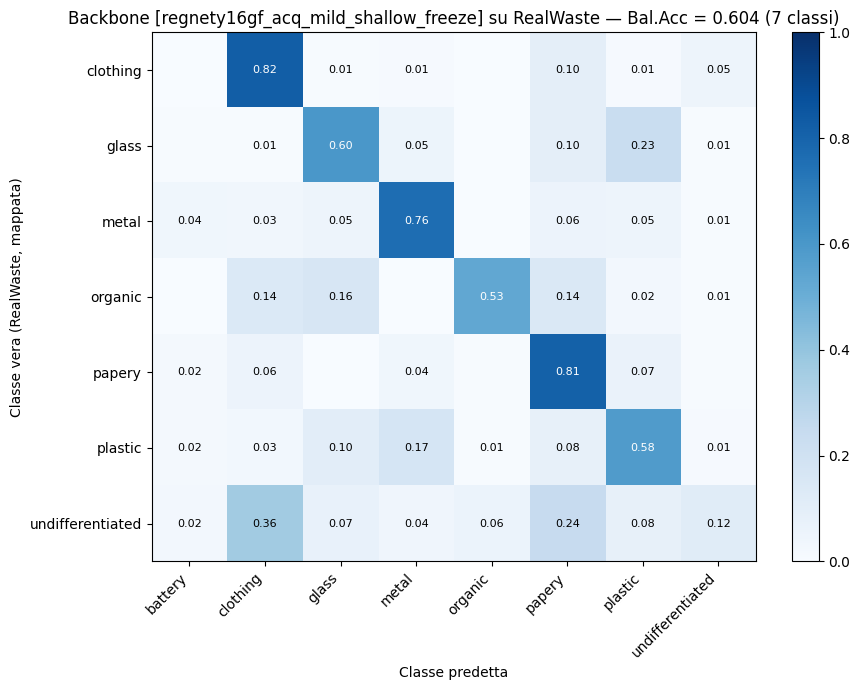

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/realwaste_confusion_regnety16gf_acq_mild_shallow_freeze.png


In [9]:
import matplotlib.pyplot as plt

# Matrice di confusione

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_present = cm[present, :]                                                     # righe: solo classi vere coperte
row_sums = cm_present.sum(axis=1, keepdims=True)
cm_norm = cm_present / np.maximum(row_sums, 1)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(present)))
ax.set_yticklabels([LABEL_NAMES[c] for c in present])
ax.set_xlabel('Classe predetta')
ax.set_ylabel('Classe vera (RealWaste, mappata)')
ax.set_title(f'Backbone [{RUN_TAG}] su RealWaste — Bal.Acc = {bal_acc:.3f} ({len(present)} classi)')
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        v = cm_norm[i, j]
        if v >= 0.005:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v > 0.5 else 'black', fontsize=8)
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
out_png = RESULTS_DIR / f'realwaste_confusion_{RUN_TAG}.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print('Salvato:', out_png)

In [10]:
import pandas as pd

# Salvataggio dei TPR per classe
df = pd.DataFrame({
    'class': [LABEL_NAMES[c] for c in present],
    'label': present,
    'n_samples': [int((y_true == c).sum()) for c in present],
    'tpr_realwaste': tpr,
})
out_csv = RESULTS_DIR / f'realwaste_per_class_tpr_{RUN_TAG}.csv'
df.to_csv(out_csv, index=False)
print('Salvato:', out_csv)

summary = pd.DataFrame([{
    'run_tag': RUN_TAG,
    'weights': WEIGHTS_PATH.name,
    'balanced_accuracy_ood': round(float(bal_acc), 4),
    'n_classes': len(present),
    'n_samples': int(len(y_true)),
}])
summary_csv = RESULTS_DIR / f'realwaste_summary_{RUN_TAG}.csv'
summary.to_csv(summary_csv, index=False)
print('Salvato:', summary_csv)
df

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/realwaste_per_class_tpr_regnety16gf_acq_mild_shallow_freeze.csv
Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/realwaste_summary_regnety16gf_acq_mild_shallow_freeze.csv


,class,label,n_samples,tpr_realwaste
0,clothing,1,318,0.823899
1,glass,2,420,0.600000
2,metal,3,790,0.764557
3,organic,4,847,0.527745
4,papery,5,961,0.811655
5,plastic,6,921,0.580890
6,undifferentiated,7,495,0.117172


## Analisi qualitativa dei misclassificati

Errori totali: 1814 / 4752  (38.2%)

Coppie (vera -> predetta) piu frequenti:
  undifferentiated -> clothing        : 178
  plastic          -> metal           : 158
  organic          -> glass           : 137
  organic          -> papery          : 120
  undifferentiated -> papery          : 120
  organic          -> clothing        : 116
  glass            -> plastic         : 97
  plastic          -> glass           : 96


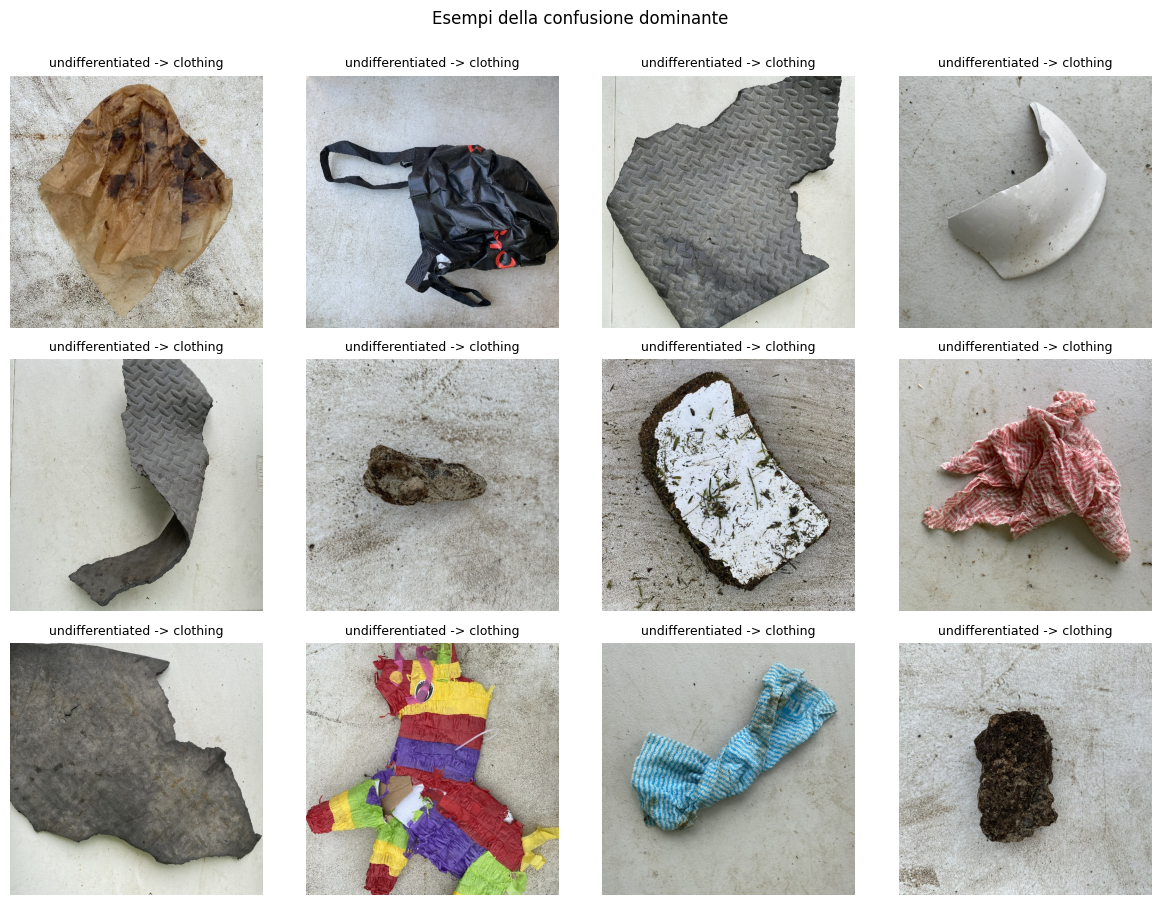

In [11]:
# Mostra un campione di errori per la coppia (vera -> predetta) più frequente

err_idx = np.where(y_true != y_pred)[0]
print(f'Errori totali: {len(err_idx)} / {len(y_true)}  ({100*len(err_idx)/len(y_true):.1f}%)')

pairs = Counter((int(y_true[i]), int(y_pred[i])) for i in err_idx)
print('\nCoppie (vera -> predetta) piu frequenti:')
for (t, p), n in pairs.most_common(8):
    print(f'  {LABEL_NAMES[t]:16s} -> {LABEL_NAMES[p]:16s}: {n}')

# Griglia con i primi esempi della coppia dominante
(t_top, p_top), _ = pairs.most_common(1)[0]
sel = [i for i in err_idx if y_true[i] == t_top and y_pred[i] == p_top][:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, i in zip(axes.flat, sel):
    ax.imshow(Image.open(records[i][0]).convert('RGB'))
    ax.set_title(f'{LABEL_NAMES[t_top]} -> {LABEL_NAMES[p_top]}', fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(sel):]:
    ax.axis('off')
plt.suptitle('Esempi della confusione dominante', y=1.0)
plt.tight_layout()
plt.show()